In [23]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from scipy.spatial.distance import cdist

In [24]:
# Carregar o dataset gerado anteriormente
df = pd.read_csv("clientes_dataset.csv")

In [25]:
df.head()

,ID_Cliente,Idade,Gênero,Renda_Anual,Frequência_Compra,Ticket_Médio,Pontuação_Fidelidade
0,1,56,Feminino,25895,12,136,51
1,2,69,Feminino,39738,2,153,81
2,3,46,Masculino,50746,3,77,5
3,4,32,Masculino,69377,12,63,29
4,5,60,Feminino,68404,1,192,4


In [26]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 7 columns):
 #   Column                Non-Null Count  Dtype 
---  ------                --------------  ----- 
 0   ID_Cliente            200 non-null    int64 
 1   Idade                 200 non-null    int64 
 2   Gênero                200 non-null    object
 3   Renda_Anual           200 non-null    int64 
 4   Frequência_Compra     200 non-null    int64 
 5   Ticket_Médio          200 non-null    int64 
 6   Pontuação_Fidelidade  200 non-null    int64 
dtypes: int64(6), object(1)
memory usage: 11.1+ KB


In [27]:
# Selecionar as colunas para clusterização
features = ["Renda_Anual", "Frequência_Compra", 
            "Ticket_Médio", "Pontuação_Fidelidade"]
df_features = df[features]

In [28]:
df_features.head()

,Renda_Anual,Frequência_Compra,Ticket_Médio,Pontuação_Fidelidade
0,25895,12,136,51
1,39738,2,153,81
2,50746,3,77,5
3,69377,12,63,29
4,68404,1,192,4


In [29]:
# Normalizar os dados
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df_features)

In [30]:
X_scaled

array([[-1.56821   ,  1.03821067, -0.94853451,  0.09051035],
       [-1.09227498, -1.37063079, -0.82389135,  1.09432205],
       [-0.71380986, -1.12974664, -1.38111963, -1.44866758],
       [-0.07325903,  1.03821067, -1.48376695, -0.64561822],
       [-0.10671166, -1.61151493, -0.53794525, -1.48212797],
       [ 0.08723109, -1.61151493, -0.63326062, -1.28136563],
       [ 1.59459357,  1.27909481, -0.53794525,  0.2578123 ],
       [-0.40286886, -1.12974664,  0.51785571, -1.0471429 ],
       [-1.57835237,  0.79732652,  0.41520839,  0.86009932],
       [ 1.48361197, -0.64797835, -0.71391208, -1.0471429 ],
       [ 1.43269384,  1.03821067, -1.21981671,  1.19470322],
       [-0.36938185, -1.12974664,  0.93577692,  1.32854478],
       [ 0.79197109, -1.61151493, -0.24466721,  0.69279737],
       [-0.19919632, -1.61151493, -0.31798672, -0.47831627],
       [ 0.18315384,  0.07467408,  0.04127888, -1.41520719],
       [ 0.76450074,  0.55644237, -0.12735599,  0.15743113],
       [ 0.17132681,  0.

In [31]:
# Encontrar o número ideal de clusters usando o método do cotovelo
distortions = []
K_range = range(1, 11)
for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_scaled)
    distortions.append(sum(np.min(cdist(X_scaled, kmeans.cluster_centers_, 'euclidean'), 
                                  axis=1)) / X_scaled.shape[0])

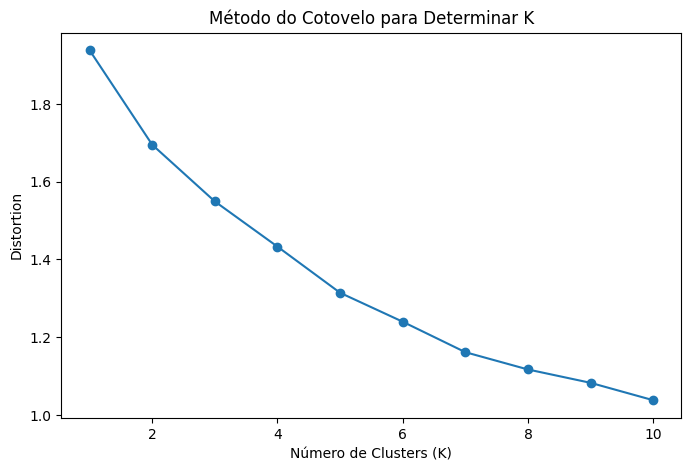

In [32]:
plt.figure(figsize=(8, 5))
plt.plot(K_range, distortions, marker='o')
plt.xlabel('Número de Clusters (K)')
plt.ylabel('Distortion')
plt.title('Método do Cotovelo para Determinar K')
plt.show()

In [33]:
# Aplicar K-Means com o valor de K escolhido (exemplo: K=4)
kmeans = KMeans(n_clusters=6, random_state=42, n_init=10)
df['Cluster'] = kmeans.fit_predict(X_scaled)

In [34]:
df.head()

,ID_Cliente,Idade,Gênero,Renda_Anual,Frequência_Compra,Ticket_Médio,Pontuação_Fidelidade,Cluster
0,1,56,Feminino,25895,12,136,51,2
1,2,69,Feminino,39738,2,153,81,4
2,3,46,Masculino,50746,3,77,5,0
3,4,32,Masculino,69377,12,63,29,3
4,5,60,Feminino,68404,1,192,4,0


In [35]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 8 columns):
 #   Column                Non-Null Count  Dtype 
---  ------                --------------  ----- 
 0   ID_Cliente            200 non-null    int64 
 1   Idade                 200 non-null    int64 
 2   Gênero                200 non-null    object
 3   Renda_Anual           200 non-null    int64 
 4   Frequência_Compra     200 non-null    int64 
 5   Ticket_Médio          200 non-null    int64 
 6   Pontuação_Fidelidade  200 non-null    int64 
 7   Cluster               200 non-null    int32 
dtypes: int32(1), int64(6), object(1)
memory usage: 11.8+ KB


In [36]:
df['Cluster'].value_counts()

Cluster
2    37
1    36
3    35
0    34
4    30
5    28
Name: count, dtype: int64

In [37]:
# Selecionar somente colunas numéricas
df_numericas = df.select_dtypes(include=["number"])


In [38]:
# Analisar os clusters formados
cluster_summary = df_numericas.groupby("Cluster").mean()

In [39]:
cluster_summary

,ID_Cliente,Idade,Renda_Anual,Frequência_Compra,Ticket_Médio,Pontuação_Fidelidade
Cluster,,,,,,
0,94.058824,44.558824,88405.852941,4.588235,156.764706,18.764706
1,98.277778,42.777778,53153.916667,11.611111,376.333333,67.500000
2,101.621622,41.594595,37502.162162,6.297297,220.297297,31.189189
3,91.085714,44.285714,92553.314286,11.657143,151.371429,61.885714
4,100.466667,43.766667,70466.900000,3.300000,307.400000,80.966667
5,121.500000,43.857143,94331.000000,8.000000,411.607143,30.071429


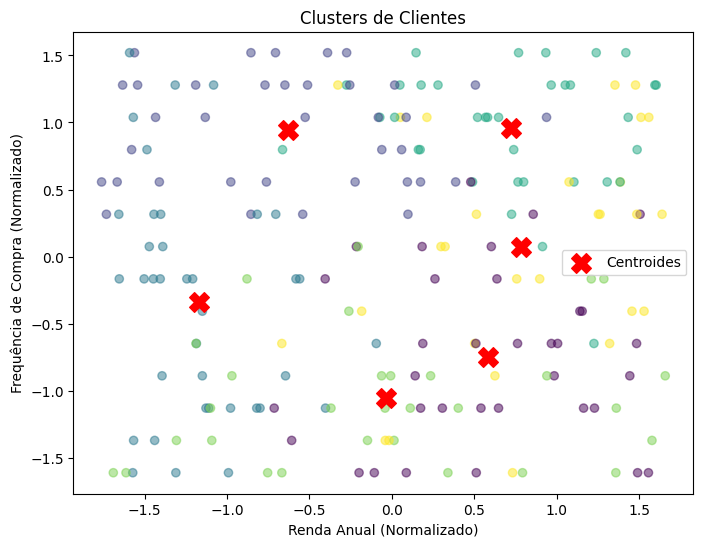

In [40]:
# Visualização dos clusters
plt.figure(figsize=(8, 6))
plt.scatter(X_scaled[:, 0], X_scaled[:, 1], c=df['Cluster'], cmap='viridis', alpha=0.5)
plt.scatter(kmeans.cluster_centers_[:, 0], kmeans.cluster_centers_[:, 1], marker='X', c='red', s=200, label='Centroides')
plt.xlabel("Renda Anual (Normalizado)")
plt.ylabel("Frequência de Compra (Normalizado)")
plt.title("Clusters de Clientes")
plt.legend()
plt.show()

In [41]:
# Métrica A: Inércia (WCSS - Within-Cluster Sum of Squares)
print(f"Inércia (WCSS): {kmeans.inertia_:.2f}")

Inércia (WCSS): 344.48


In [42]:
# Métrica B: Coeficiente de Silhueta (Silhouette Score)
from sklearn.metrics import silhouette_score
silhouette_avg = silhouette_score(X_scaled, kmeans.labels_)
print(f"Coeficiente de Silhueta Médio: {silhouette_avg:.4f}")

Coeficiente de Silhueta Médio: 0.2356


In [43]:
# Métrica C: Índice Davies-Bouldin
from sklearn.metrics import davies_bouldin_score
db_index = davies_bouldin_score(X_scaled, kmeans.labels_)
print(f"Índice Davies-Bouldin: {db_index:.4f}")

Índice Davies-Bouldin: 1.2218


In [44]:
# Comparação das métricas com score de desempenho para rankeamento
import pandas as pd
import numpy as np
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, davies_bouldin_score

k_values = [2, 3, 4, 5, 6]
results = []

for k in k_values:
    kmeans_temp = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans_temp.fit_predict(X_scaled)
    
    inertia = kmeans_temp.inertia_
    silhouette = silhouette_score(X_scaled, labels)
    db_index = davies_bouldin_score(X_scaled, labels)
    
    results.append({
        "K": k,
        "Inércia (WCSS)": round(inertia, 2),
        "Silhueta": round(silhouette, 4),
        "Davies-Bouldin": round(db_index, 4)
    })

df_metrics = pd.DataFrame(results)

# Normalização Min-Max para combinar as métricas de forma justa (0 a 1)
s_min, s_max = df_metrics["Silhueta"].min(), df_metrics["Silhueta"].max()
db_min, db_max = df_metrics["Davies-Bouldin"].min(), df_metrics["Davies-Bouldin"].max()

# Normalizar Silhueta (quanto maior melhor -> 1 é o melhor)
norm_s = (df_metrics["Silhueta"] - s_min) / (s_max - s_min) if s_max != s_min else 1.0
# Normalizar Davies-Bouldin (quanto menor melhor -> 0 é o melhor, invertemos para 1 ser o melhor)
norm_db = (df_metrics["Davies-Bouldin"] - db_min) / (db_max - db_min) if db_max != db_min else 0.0
norm_db_inv = 1 - norm_db

# Score final (média das duas métricas normalizadas)
df_metrics["Score de Desempenho (0 a 1)"] = round((norm_s + norm_db_inv) / 2, 4)

# Ordenar do melhor para o pior score
df_metrics.sort_values(by="Score de Desempenho (0 a 1)", ascending=False, inplace=True)
df_metrics.set_index("K", inplace=True)
df_metrics

,Inércia (WCSS),Silhueta,Davies-Bouldin,Score de Desempenho (0 a 1)
K,,,,
6,344.48,0.2356,1.2218,0.9726
5,382.75,0.2378,1.2675,0.9623
4,450.92,0.2142,1.4678,0.5025
3,527.16,0.1977,1.5665,0.2153
2,628.48,0.2082,1.8271,0.1309


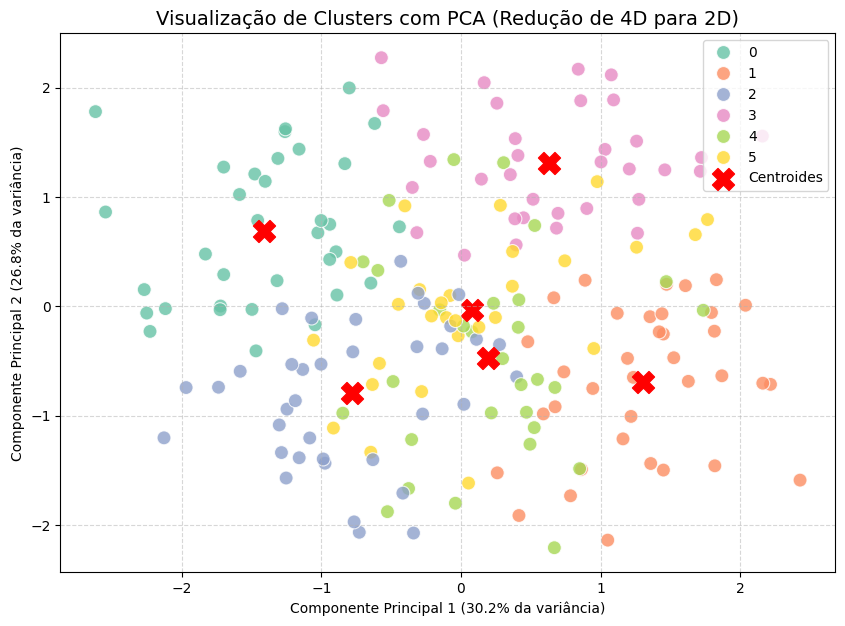

In [45]:
# Visualização de Clusters com PCA (Redução de 4D para 2D)
from sklearn.decomposition import PCA
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Aplicar o PCA para reduzir de 4D para 2D
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

# 2. Criar DataFrame para plotagem
df_pca = pd.DataFrame(X_pca, columns=['PCA1', 'PCA2'])
df_pca['Cluster'] = df['Cluster']

# 3. Projetar os centroides no espaço PCA
centroids_pca = pca.transform(kmeans.cluster_centers_)

# 4. Plotar com Seaborn
plt.figure(figsize=(10, 7))
sns.scatterplot(
    x='PCA1', y='PCA2',
    hue='Cluster',
    data=df_pca,
    palette='Set2',
    s=100,
    alpha=0.8,
    legend='full'
)
plt.scatter(centroids_pca[:, 0], centroids_pca[:, 1], marker='X', c='red', s=250, label='Centroides')

plt.title('Visualização de Clusters com PCA (Redução de 4D para 2D)', fontsize=14)
plt.xlabel(f'Componente Principal 1 ({pca.explained_variance_ratio_[0]*100:.1f}% da variância)')
plt.ylabel(f'Componente Principal 2 ({pca.explained_variance_ratio_[1]*100:.1f}% da variância)')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

In [46]:
# Gráfico Interativo com Plotly
import plotly.express as px
import plotly.graph_objects as go

df_plot = df.copy()
df_plot['Cluster'] = df_plot['Cluster'].astype(str)

fig = px.scatter(
    df_plot,
    x='Renda_Anual',
    y='Frequência_Compra',
    color='Cluster',
    size='Ticket_Médio',
    hover_data=['ID_Cliente', 'Idade', 'Gênero', 'Pontuação_Fidelidade'],
    title='Análise Interativa de Clusters de Clientes',
    color_discrete_sequence=px.colors.qualitative.Safe
)

# Calcular os centroides no espaço original
centroids_orig = scaler.inverse_transform(kmeans.cluster_centers_)

# Adicionar os centroides ao gráfico 2D
fig.add_trace(go.Scatter(
    x=centroids_orig[:, 0],
    y=centroids_orig[:, 1],
    mode='markers',
    marker=dict(
        size=15,
        color='black',
        symbol='x',
        line=dict(color='white', width=2)
    ),
    name='Centroides'
))

fig.update_layout(
    xaxis_title="Renda Anual ($)",
    yaxis_title="Frequência de Compra",
    legend_title="Clusters",
    template="plotly_white",
    width=900,
    height=600
)
fig.show()


In [47]:
# Gráfico de Coordenadas Paralelas (Distribuição em todas as variáveis originais)
import plotly.express as px

fig = px.parallel_coordinates(
    df,
    color="Cluster",
    dimensions=["Renda_Anual", "Frequência_Compra", "Ticket_Médio", "Pontuação_Fidelidade"],
    color_continuous_scale=px.colors.diverging.Tealrose,
    title="Perfil dos Clientes por Variável"
)
fig.show()

In [48]:
# Gráfico de Dispersão 3D Interativo com Plotly
import plotly.express as px
import plotly.graph_objects as go

df_plot = df.copy()
df_plot['Cluster'] = df_plot['Cluster'].astype(str)

fig = px.scatter_3d(
    df_plot, 
    x='Renda_Anual', 
    y='Frequência_Compra', 
    z='Pontuação_Fidelidade',
    color='Cluster',
    size='Ticket_Médio',
    hover_data=['ID_Cliente', 'Idade', 'Gênero'],
    title='Visualização Interativa em 3D dos Clusters de Clientes',
    color_discrete_sequence=px.colors.qualitative.Safe
)

# Calcular os centroides no espaço original
centroids_orig = scaler.inverse_transform(kmeans.cluster_centers_)

# Adicionar os centroides ao gráfico 3D
fig.add_trace(go.Scatter3d(
    x=centroids_orig[:, 0],
    y=centroids_orig[:, 1],
    z=centroids_orig[:, 3],
    mode='markers',
    marker=dict(
        size=10,
        color='black',
        symbol='diamond',
        line=dict(color='white', width=2)
    ),
    name='Centroides'
))

fig.update_layout(
    scene = dict(
        xaxis_title='Renda Anual ($)',
        yaxis_title='Frequência de Compra',
        zaxis_title='Pontuação de Fidelidade'
    ),
    width=900,
    height=700
)
fig.show()
